# GTEx tissue feature importance analysis (K-means binary + SHAP)

1. Load GTEx LV data, tissue metadata, and the saved K-means model
2. Derive binary tissue labels from K-means cluster assignments (majority-vote tissue per cluster)
3. For each tissue, train a binary RF classifier (tissue vs. rest) using k-means-derived labels
4. Compute SHAP values to explain which LVs drive each tissue
5. Downstream: specificity heatmap, trait associations, GO BP pathways

💡 **Environment:** `clamp-analyses`

In [1]:
import os
import pickle
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns

from pyprojroot.here import here
import shap

import rpy2.robjects as ro
from rpy2.robjects.conversion import localconverter
from rpy2.robjects import pandas2ri
readRDS = ro.r["readRDS"]

import csv
import re
import textwrap
import urllib.request
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
from itertools import groupby

np.random.seed(42)

/home/msubirana/miniconda3/envs/clamp-analyses/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Settings

# Output

In [2]:
OUTPUT_DIR = here('output/gtex_feature_importance_kmeans_binary_shap')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Output directory: {OUTPUT_DIR}")

Output directory: /home/msubirana/Documents/pivlab/clamp-analyses/output/gtex_feature_importance_kmeans_binary_shap


# Load data

In [3]:
# load .rds files from CLAMP with different priors
gtex_CLAMPfull_rds = readRDS(str(here('output/gtex/CLAMPfull.rds')))


def extract_B_matrix(rds_obj):
    B_matrix = rds_obj.rx2("B")
    with localconverter(ro.default_converter + pandas2ri.converter):
        B_values = ro.conversion.rpy2py(B_matrix)
    df = pd.DataFrame(
        data=B_values,
        index=B_matrix.rownames if B_matrix.rownames else None,
        columns=B_matrix.colnames if B_matrix.colnames else None,
    )
    return df

gtex_CLAMPfull = extract_B_matrix(gtex_CLAMPfull_rds)

lv_data = gtex_CLAMPfull
lv_data.head()

,GTEX-1117F-0226-SM-5GZZ7,GTEX-1117F-0426-SM-5EGHI,GTEX-1117F-0526-SM-5EGHJ,GTEX-1117F-0626-SM-5N9CS,GTEX-1117F-0726-SM-5GIEN,GTEX-1117F-1326-SM-5EGHH,GTEX-1117F-2426-SM-5EGGH,GTEX-1117F-2526-SM-5GZY6,GTEX-1117F-2826-SM-5GZXL,GTEX-1117F-2926-SM-5GZYI,...,GTEX-ZZPU-1126-SM-5N9CW,GTEX-ZZPU-1226-SM-5N9CK,GTEX-ZZPU-1326-SM-5GZWS,GTEX-ZZPU-1426-SM-5GZZ6,GTEX-ZZPU-1826-SM-5E43L,GTEX-ZZPU-2126-SM-5EGIU,GTEX-ZZPU-2226-SM-5EGIV,GTEX-ZZPU-2426-SM-5E44I,GTEX-ZZPU-2626-SM-5E45Y,GTEX-ZZPU-2726-SM-5NQ8O
LV1,0.038220,-0.035718,0.058029,0.046667,0.014035,-0.002800,0.036971,0.029603,0.075848,0.070109,...,-0.074388,0.060693,0.008793,0.000346,-0.064704,0.015187,0.001466,-0.066104,-0.145394,0.006629
LV2,-0.172913,-0.142436,-0.177395,-0.129254,-0.142321,-0.174625,-0.172582,-0.079782,-0.184006,-0.092761,...,-0.140227,-0.095136,-0.129896,-0.109970,-0.114404,-0.178207,-0.090775,-0.173437,-0.175773,-0.177160
LV3,-0.052967,-0.119714,0.045306,-0.177612,-0.004371,-0.013131,0.071965,-0.072757,-0.003389,0.054140,...,0.031745,1.396569,-0.218557,0.123030,-0.091181,0.613276,0.111563,0.140791,-0.073572,-0.006682
LV4,0.684940,0.194151,0.258987,0.042777,0.297042,0.270592,0.071725,-0.321013,0.272885,0.105102,...,0.162523,-0.028583,0.097821,0.032877,-0.020901,-0.004998,-0.422042,-0.002357,-0.126704,0.265592
LV5,0.238198,0.206424,0.082470,0.006714,0.030963,0.042211,-0.158377,-0.226136,0.080164,-0.183551,...,0.009347,-0.006413,-0.007506,0.160013,-0.028191,-0.011097,-0.354041,-0.074878,0.058859,0.121228


In [4]:
def extract_summary_matrix(rds_obj):
    summary_matrix = rds_obj.rx2("summary")
    with localconverter(ro.default_converter + pandas2ri.converter):
        summary_values = ro.conversion.rpy2py(summary_matrix)
    df = pd.DataFrame(
        data=summary_values,
        index=summary_matrix.rownames if summary_matrix.rownames else None,
        columns=summary_matrix.colnames if summary_matrix.colnames else None,
    )
    return df

gtex_CLAMPfull_summary = extract_summary_matrix(gtex_CLAMPfull_rds)
gtex_CLAMPfull_summary["pathway"] = gtex_CLAMPfull_summary["pathway"].str.replace("C2CP_", "", regex=False)

print(gtex_CLAMPfull_summary.shape)
gtex_CLAMPfull_summary.head()

(4160, 7)


,pathway,LV,AUC,p_value,FDR,npos,nneg
BP529,BP_Calcium-Independent Cell-Cell Adhesion via ...,LV1,0.606766,0.289486,0.700379,2,21512
BP878,BP_Defense Response to Symbiont (GO:0140546),LV1,0.240866,0.911012,0.948822,2,21512
BP1258,BP_Glycolipid Catabolic Process (GO:0019377),LV1,0.240866,0.911012,0.948822,2,21512
BP2301,BP_Negative Regulation of Programmed Necrotic ...,LV1,0.529042,0.440030,0.780830,2,21512
BP3194,BP_Positive Regulation of Macrophage Different...,LV1,0.722759,0.123478,0.459043,2,21512


In [5]:
path = here('data/gtex/GTEx_Analysis_v8_Annotations_SampleAttributesDS.txt')

gtex_meta = pd.read_csv(
    path,
    sep='\t',
    header=0,
    dtype=str,
    quoting=csv.QUOTE_NONE,
    engine='python',
    comment=None,
    keep_default_na=False,
    on_bad_lines='warn'
)

print(gtex_meta.shape)
gtex_meta.head()

(22951, 63)


,SAMPID,SMATSSCR,SMCENTER,SMPTHNTS,SMRIN,SMTS,SMTSD,SMUBRID,SMTSISCH,SMTSPAX,...,SME1ANTI,SMSPLTRD,SMBSMMRT,SME1SNSE,SME1PCTS,SMRRNART,SME1MPRT,SMNUM5CD,SMDPMPRT,SME2PCTS
0,GTEX-1117F-0003-SM-58Q7G,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
1,GTEX-1117F-0003-SM-5DWSB,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
2,GTEX-1117F-0003-SM-6WBT7,,B1,,,Blood,Whole Blood,0013756,1188,,...,,,,,,,,,,
3,GTEX-1117F-0011-R10a-SM-AHZ7F,,"B1, A1",,,Brain,Brain - Frontal Cortex (BA9),0009834,1193,,...,,,,,,,,,,
4,GTEX-1117F-0011-R10b-SM-CYKQ8,,"B1, A1",,7.2,Brain,Brain - Frontal Cortex (BA9),0009834,1193,,...,,,,,,,,,,


In [6]:
# transpose to get samples as rows, LVs as columns
lv_matrix = lv_data.T

# filter metadata to only include samples in LV matrix
meta_filtered = gtex_meta[gtex_meta['SAMPID'].isin(lv_matrix.index)].copy()
meta_filtered = meta_filtered.set_index('SAMPID')
meta_filtered = meta_filtered.loc[lv_matrix.index]

tissue_labels = meta_filtered['SMTSD']

print(f"Number of samples: {len(lv_matrix)}")
print(f"Number of LVs: {lv_matrix.shape[1]}")
print(f"Number of unique tissues: {tissue_labels.nunique()}")
print(f"\nTissue distribution:")
print(tissue_labels.value_counts().head())

Number of samples: 17382
Number of LVs: 578
Number of unique tissues: 54

Tissue distribution:
SMTSD
Muscle - Skeletal                 803
Whole Blood                       755
Skin - Sun Exposed (Lower leg)    701
Adipose - Subcutaneous            663
Artery - Tibial                   663
Name: count, dtype: int64


In [7]:
phenoplier_path = here('data/gtex/phenoplier/gtex-gls-summary-phenomexcan.tsv.gz')

phenoplier = pd.read_csv(
    phenoplier_path,
    sep="\t",
    compression="gzip",
    low_memory=False
)

print(phenoplier.shape)
print(phenoplier.columns.tolist())

(1668188, 5)
['phenotype', 'phenotype_desc', 'lv', 'pvalue', 'fdr']


# Load K-means model

Load the K-means model trained in `00_kmeans_clustering.ipynb`.
Cluster labels are used to derive binary tissue labels for each RF.

In [8]:
model_path = here('output/gtex/kmeans_models/gtex_CLAMPfull_kmeans_model.pkl')

with open(model_path, 'rb') as f:
    model_bundle = pickle.load(f)

km_model = model_bundle['model']
km_scaler = model_bundle['scaler']
best_k = model_bundle['best_k']
best_approach = model_bundle['best_approach']
saved_ari = model_bundle['ari']

print(f"K-means model: k={best_k}, approach={best_approach}, ARI={saved_ari:.4f}")

# apply the same preprocessing and get cluster assignments
if best_approach == 'scaled':
    X_km = km_scaler.transform(lv_matrix.astype(np.float32))
else:
    X_km = lv_matrix.values.astype(np.float32)

cluster_labels = km_model.predict(X_km)

# verify ARI matches
reproduced_ari = adjusted_rand_score(tissue_labels.values, cluster_labels)
print(f"Reproduced ARI: {reproduced_ari:.4f} (saved: {saved_ari:.4f})")

# map clusters to tissues (majority vote)
cluster_tissue_map = {}
cluster_tissue_purity = {}

for c in range(best_k):
    mask = cluster_labels == c
    cluster_tissues = tissue_labels[mask]
    dominant_tissue = cluster_tissues.value_counts().index[0]
    purity = cluster_tissues.value_counts().iloc[0] / len(cluster_tissues)
    cluster_tissue_map[c] = dominant_tissue
    cluster_tissue_purity[c] = purity

# group clusters by dominant tissue
tissue_to_clusters = defaultdict(list)
for c, tissue in cluster_tissue_map.items():
    tissue_to_clusters[tissue].append(c)

# cluster summary
cluster_summary = pd.DataFrame({
    'Cluster': range(best_k),
    'Dominant_Tissue': [cluster_tissue_map[c] for c in range(best_k)],
    'Purity': [cluster_tissue_purity[c] for c in range(best_k)],
    'Size': [np.sum(cluster_labels == c) for c in range(best_k)]
}).sort_values('Dominant_Tissue')

print(f"\nCluster summary ({best_k} clusters):")
display(cluster_summary)

# binary tissue labels derived from k-means (positive = sample in a cluster dominated by that tissue)
km_tissue_labels = pd.Series(
    [cluster_tissue_map[c] for c in cluster_labels],
    index=lv_matrix.index
)
print(f"\nK-means-derived tissue label distribution:")
print(km_tissue_labels.value_counts())

K-means model: k=49, approach=scaled, ARI=0.7249
Reproduced ARI: 0.7238 (saved: 0.7249)

Cluster summary (49 clusters):


,Cluster,Dominant_Tissue,Purity,Size
16,16,Adipose - Subcutaneous,0.793532,804
20,20,Adipose - Visceral (Omentum),0.862805,328
27,27,Adipose - Visceral (Omentum),0.680000,375
41,41,Adrenal Gland,1.000000,258
28,28,Artery - Aorta,0.680511,626
7,7,Artery - Tibial,0.977578,669
29,29,Brain - Caudate (basal ganglia),0.523962,313
18,18,Brain - Cerebellum,0.535147,441
11,11,Brain - Cortex,0.454780,387
8,8,Brain - Hippocampus,0.283721,430



K-means-derived tissue label distribution:
Skin - Sun Exposed (Lower leg)               1296
Esophagus - Muscularis                        895
Muscle - Skeletal                             806
Adipose - Subcutaneous                        804
Whole Blood                                   755
Adipose - Visceral (Omentum)                  703
Artery - Tibial                               669
Colon - Sigmoid                               667
Thyroid                                       645
Artery - Aorta                                626
Nerve - Tibial                                622
Lung                                          579
Esophagus - Mucosa                            571
Cells - Cultured fibroblasts                  504
Brain - Putamen (basal ganglia)               443
Brain - Cerebellum                            441
Heart - Left Ventricle                        435
Brain - Hippocampus                           430
Heart - Atrial Appendage                      423
Brain 

In [9]:
accuracy_df = pd.read_csv(OUTPUT_DIR / "accuracy_summary.tsv", sep="\t")
shap_results_df = pd.read_csv(OUTPUT_DIR / "all_shap_positive.tsv", sep="\t")
cumulative_df = pd.read_csv(OUTPUT_DIR / "cumulative_importance.tsv", sep="\t")

In [ ]:
MIN_CLUSTER_PURITY = 0.9
MIN_RF_ACCURACY = 0.9

# LV tissue annotation

For each LV, take the top 1% of samples (highest B matrix values) and annotate the LV with the dominant tissue.
Then build a heatmap showing how tissue-specific the top SHAP LVs are.

In [10]:
# annotate each LV using the top 1% of samples from the B matrix
n_top = max(1, int(len(lv_matrix) * 0.01))

lv_tissue_pct = {}
lv_tissue_annotation = {}

for lv in lv_matrix.columns:
    top_idx = lv_matrix[lv].nlargest(n_top).index
    top_tissues = tissue_labels.loc[top_idx]
    pct_dist = (top_tissues.value_counts(normalize=True) * 100).to_dict()
    lv_tissue_pct[lv] = pct_dist
    lv_tissue_annotation[lv] = top_tissues.value_counts().index[0]

lv_annot_df = pd.DataFrame({
    'LV': list(lv_tissue_annotation.keys()),
    'Annotated_Tissue': list(lv_tissue_annotation.values()),
}).set_index('LV')

print(f"top 1% = {n_top} samples per LV")
print(f"\nLV annotations per tissue:")
print(lv_annot_df['Annotated_Tissue'].value_counts())
lv_annot_df.head(10)

top 1% = 173 samples per LV

LV annotations per tissue:
Annotated_Tissue
Whole Blood                                  53
Cells - Cultured fibroblasts                 42
Nerve - Tibial                               29
Thyroid                                      29
Lung                                         28
Cells - EBV-transformed lymphocytes          26
Artery - Tibial                              24
Brain - Cerebellar Hemisphere                20
Muscle - Skeletal                            19
Ovary                                        19
Skin - Not Sun Exposed (Suprapubic)          18
Skin - Sun Exposed (Lower leg)               16
Adipose - Subcutaneous                       15
Adipose - Visceral (Omentum)                 15
Pituitary                                    15
Esophagus - Mucosa                           14
Testis                                       14
Brain - Cerebellum                           13
Liver                                        13
Artery - Aorta 

,Annotated_Tissue
LV,
LV1,Pancreas
LV2,Brain - Frontal Cortex (BA9)
LV3,Adrenal Gland
LV4,Whole Blood
LV5,Nerve - Tibial
LV6,Cells - Cultured fibroblasts
LV7,Muscle - Skeletal
LV8,Whole Blood
LV9,Heart - Left Ventricle


In [ ]:
CUMULATIVE_PCT = 40

valid_tissues = accuracy_df[
    (accuracy_df['Mean_Purity'] >= MIN_CLUSTER_PURITY) & 
    (accuracy_df['Best_Test_Balanced_Accuracy'] >= MIN_RF_ACCURACY)
]['Tissue'].tolist()

tissues_ordered = sorted(valid_tissues)

results = []
for tissue in tissues_ordered:
    df_t = cumulative_df[cumulative_df['Tissue'] == tissue].sort_values('Rank')
    mask = df_t['Cumulative_Percent'] >= CUMULATIVE_PCT
    n = int(df_t.loc[mask, 'Rank'].iloc[0]) if mask.any() else len(df_t)
    cum_at_n = df_t[df_t['Rank'] == n]['Cumulative_Percent'].values[0]
    results.append({'Tissue': tissue, 'N_lvs': n, 'CumPct': round(cum_at_n, 1)})

results_df = pd.DataFrame(results)
display(results_df)

n_per_tissue = results_df.set_index('Tissue')['N_lvs'].to_dict()
top_per_tissue = {
    tissue: shap_results_df[shap_results_df['Tissue'] == tissue]['Feature']
                .head(n_per_tissue[tissue]).tolist()
    for tissue in n_per_tissue
}

for tissue, n in sorted(n_per_tissue.items()):
    print(f"  {tissue}: {n} LVs")

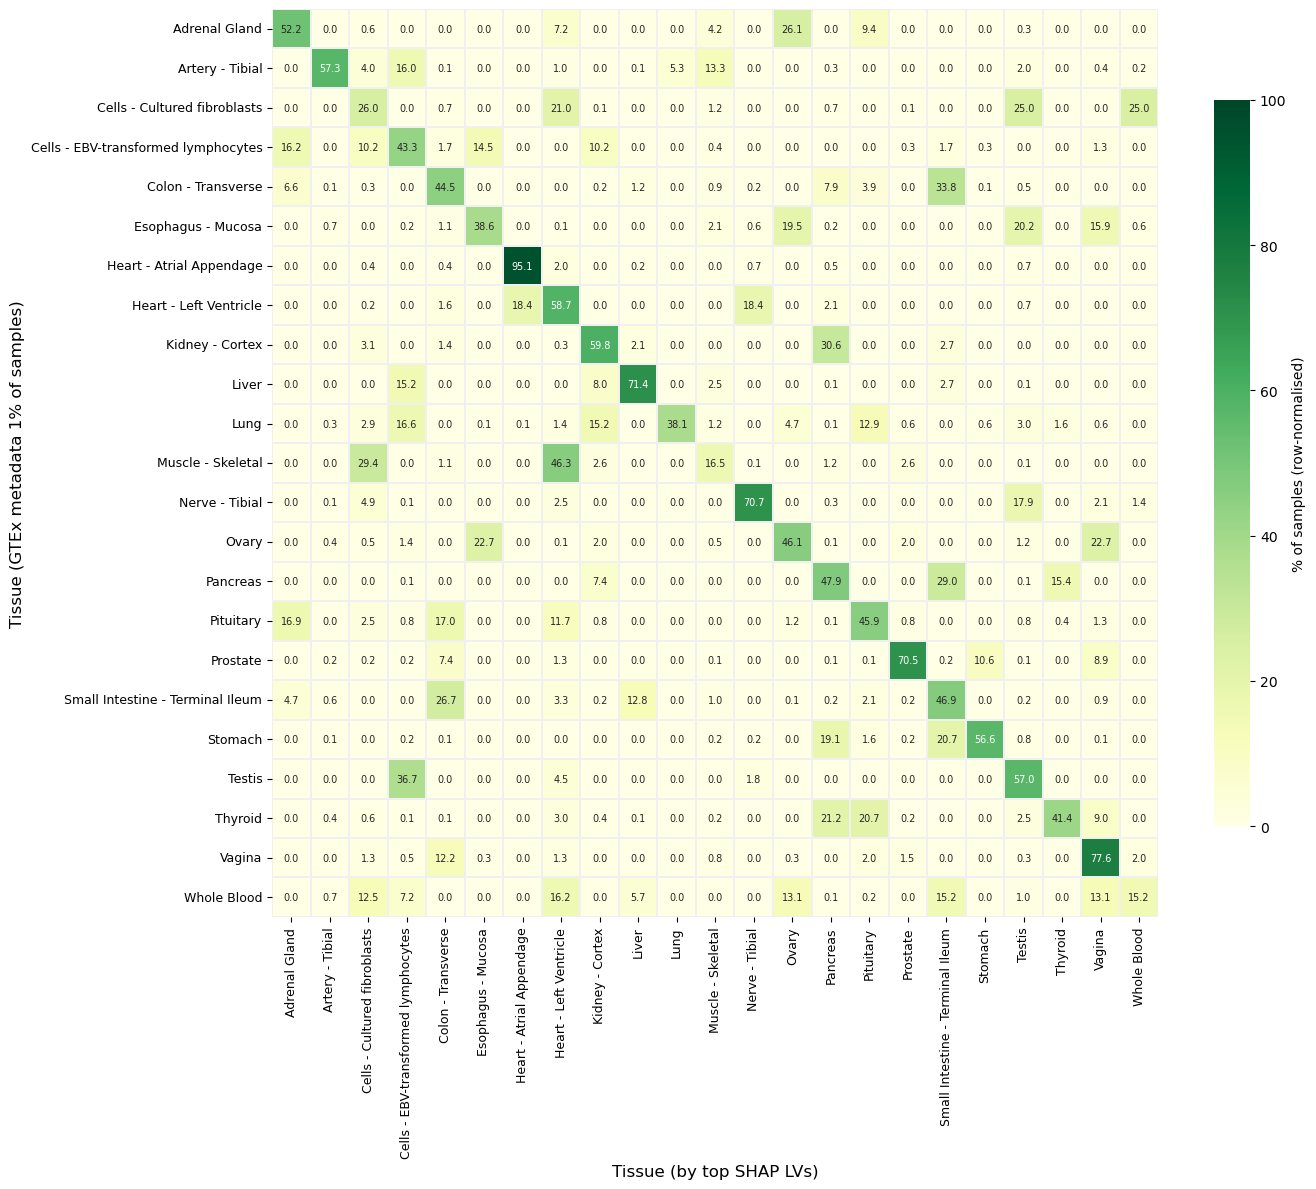

In [12]:
TOP_PCT = 0.01

n_top = max(1, int(len(lv_matrix) * TOP_PCT))
heatmap_matrix = np.zeros((len(tissues_ordered), len(tissues_ordered)))

for j, col_tissue in enumerate(tissues_ordered):
    top_lvs = top_per_tissue.get(col_tissue, [])
    pooled_tissues = []
    for lv in top_lvs:
        top_idx = lv_matrix[lv].nlargest(n_top).index
        pooled_tissues.extend(tissue_labels.loc[top_idx].tolist())
    tissue_counts = pd.Series(pooled_tissues).value_counts()
    for i, row_tissue in enumerate(tissues_ordered):
        heatmap_matrix[i, j] = tissue_counts.get(row_tissue, 0)

row_sums = heatmap_matrix.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
heatmap_matrix_norm = heatmap_matrix / row_sums * 100

heatmap_df = pd.DataFrame(heatmap_matrix_norm, index=tissues_ordered, columns=tissues_ordered)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    heatmap_df,
    cmap='YlGn',
    vmin=0, vmax=100,
    linewidths=0.3,
    linecolor='#f0f0f0',
    ax=ax,
    annot=True,
    fmt='.1f',
    annot_kws={'size': 7},
    cbar_kws={'label': '% of samples (row-normalised)', 'shrink': 0.8}
)
ax.set_xlabel('Tissue (by top SHAP LVs)', fontsize=12)
ax.set_ylabel('Tissue (GTEx metadata 1% of samples)', fontsize=12)
plt.xticks(rotation=90, fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

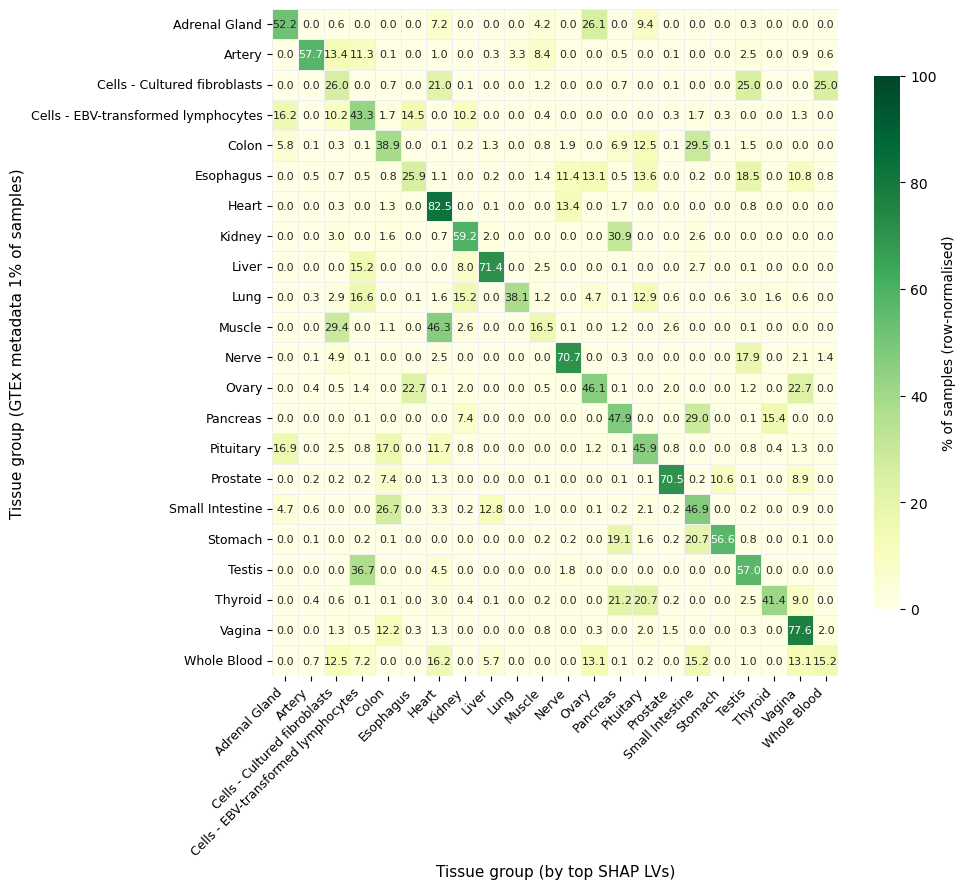

In [13]:
# Grouped heatmap (Cells - kept individual, all others merged by category)
def get_heatmap_group(name):
    if name.startswith('Cells - '):
        return name          # keep Cells subtypes separate
    return name.split(' - ')[0].strip() if ' - ' in name else name


hm_groups = sorted(set(get_heatmap_group(t) for t in tissues_ordered))

# Pool top LVs per group
group_top_lvs_hm = {}
for grp in hm_groups:
    seen_lv = set()
    lvs = []
    for tissue in tissues_ordered:
        if get_heatmap_group(tissue) == grp:
            for lv in top_per_tissue.get(tissue, []):
                if lv not in seen_lv:
                    seen_lv.add(lv)
                    lvs.append(lv)
    group_top_lvs_hm[grp] = lvs

n_grp = len(hm_groups)
hm_grp = np.zeros((n_grp, n_grp))

for j, col_grp in enumerate(hm_groups):
    pooled = []
    for lv in group_top_lvs_hm.get(col_grp, []):
        top_idx = lv_matrix[lv].nlargest(n_top).index
        pooled.extend(tissue_labels.loc[top_idx].tolist())
    if not pooled:
        continue
    grp_counts = pd.Series([get_heatmap_group(t) for t in pooled]).value_counts()
    total = len(pooled)
    for i, row_grp in enumerate(hm_groups):
        hm_grp[i, j] = grp_counts.get(row_grp, 0)

row_sums = hm_grp.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
hm_grp_norm = hm_grp / row_sums * 100
hm_grp_df = pd.DataFrame(hm_grp_norm, index=hm_groups, columns=hm_groups)

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(
    hm_grp_df,
    cmap='YlGn', vmin=0, vmax=100,
    linewidths=0.4, linecolor='#f0f0f0',
    ax=ax, annot=True, fmt='.1f',
    annot_kws={'size': 8},
    cbar_kws={'label': '% of samples (row-normalised)', 'shrink': 0.8}
)
ax.set_xlabel('Tissue group (by top SHAP LVs)', fontsize=11)
ax.set_ylabel('Tissue group (GTEx metadata 1% of samples)', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()


## LV counts per tissue

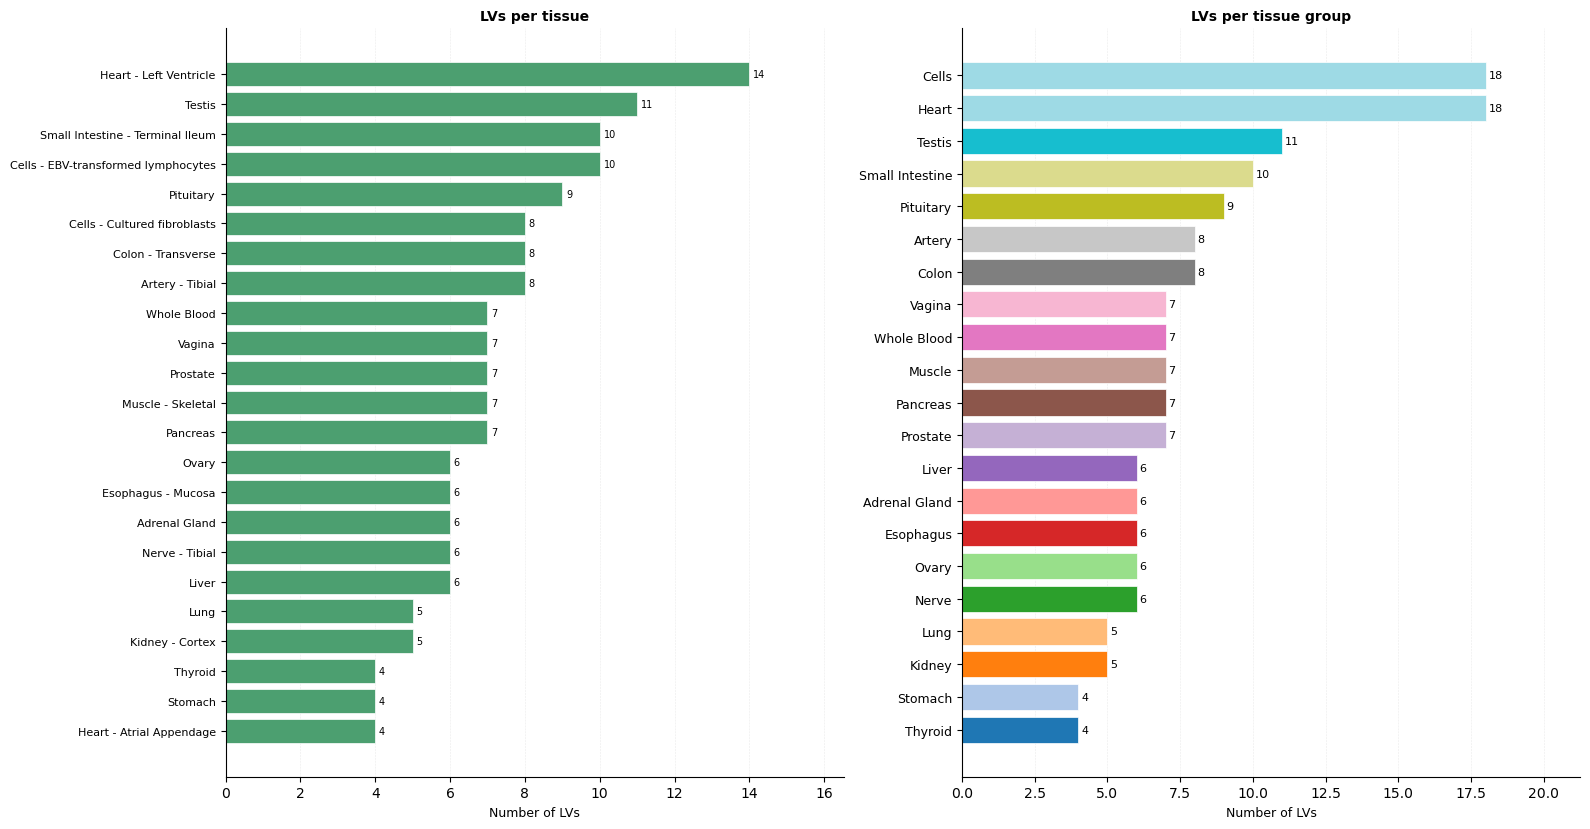

In [14]:
def get_tissue_group(name):
    """Extract main tissue category (prefix before ' - ')."""
    return name.split(" - ")[0].strip() if " - " in name else name


# individual tissue LV counts, sorted ascending
lv_counts = pd.Series(n_per_tissue).sort_values()

# grouped counts
group_counts = (
    lv_counts.rename(index=get_tissue_group)
    .groupby(level=0)
    .sum()
    .sort_values()
)

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, max(6, len(lv_counts) * 0.30 + 1.5)),
    facecolor="white"
)

# ── left: individual tissues ──────────────────────────────────────
ax = axes[0]
y_pos = np.arange(len(lv_counts))
ax.barh(y_pos, lv_counts.values, color="#4c9f70", edgecolor="white", linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(lv_counts.index, fontsize=8)
ax.set_xlabel("Number of LVs", fontsize=9)
ax.set_title("LVs per tissue", fontsize=10, fontweight="bold")
ax.set_xlim(0, lv_counts.max() * 1.18)
for i, v in enumerate(lv_counts.values):
    ax.text(v + 0.1, i, str(int(v)), va="center", fontsize=7)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.grid(axis="x", linestyle="--", linewidth=0.4, alpha=0.4, color="#cccccc")
ax.set_axisbelow(True)

# ── right: grouped tissues ────────────────────────────────────────
ax = axes[1]
y_pos = np.arange(len(group_counts))
cmap_tab = plt.cm.tab20
colors = [cmap_tab(i / max(len(group_counts) - 1, 1)) for i in range(len(group_counts))]
ax.barh(y_pos, group_counts.values, color=colors, edgecolor="white", linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(group_counts.index, fontsize=9)
ax.set_xlabel("Number of LVs", fontsize=9)
ax.set_title("LVs per tissue group", fontsize=10, fontweight="bold")
ax.set_xlim(0, group_counts.max() * 1.18)
for i, v in enumerate(group_counts.values):
    ax.text(v + 0.1, i, str(int(v)), va="center", fontsize=8)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
ax.grid(axis="x", linestyle="--", linewidth=0.4, alpha=0.4, color="#cccccc")
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


## Traits

In [15]:
phenoplier_filtered = (
    phenoplier.loc[phenoplier["fdr"] < 0.01, ["phenotype", "phenotype_desc", "lv", "fdr"]]
    .sort_values("fdr")
    .rename(columns={"phenotype": "pheno_id", "phenotype_desc": "phenotype", "lv": "LV"})
)

display(phenoplier_filtered.head())
phenoplier_filtered.shape

,pheno_id,phenotype,LV,fdr
278512,30240_raw,Reticulocyte percentage,LV52,1.764320e-31
637364,30190_raw,Monocyte percentage,LV250,8.767880e-31
1402860,30250_raw,Reticulocyte count,LV52,7.587580e-28
1014344,20002_1456,"Non-cancer illness code, self-reported: malabs...",LV324,1.316910e-27
1475372,30280_raw,Immature reticulocyte fraction,LV52,2.916400e-25


(1783, 4)

In [16]:
pheno_info_path = here('output/gtex/phenomexcan_simplified_phenotypes_info.tsv.gz')
if not pheno_info_path.exists():
    url = "https://zenodo.org/records/14941353/files/phenomexcan-phenotypes_info.tsv.gz?download=1"
    urllib.request.urlretrieve(url, pheno_info_path)
    print(f"downloaded to {pheno_info_path}")

pheno_info = pd.read_csv(pheno_info_path, sep='\t', compression='gzip', index_col='pheno_id')

pheno_info['n_eff'] = pheno_info['n'].combine_first(
    pheno_info['n_cases'] + pheno_info['n_controls']
)
desc_to_n = (
    pheno_info.dropna(subset=['n_eff'])
    .groupby('description')['n_eff']
    .max()
    .astype(int)
    .to_dict()
)

print(f"loaded {len(pheno_info)} phenotypes, {len(desc_to_n)} with n info")
pheno_info.head()

loaded 4091 phenotypes, 4034 with n info


/tmp/ipykernel_2591339/802143465.py:9: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  pheno_info['n_eff'] = pheno_info['n'].combine_first(


,full_code,short_code,description,unique_description,type,n,n_cases,n_controls,source,n_eff
pheno_id,,,,,,,,,,
0,100001_raw-Food_weight,100001_raw,Food weight,Food weight,continuous_raw,51453,NaN,NaN,UK Biobank,51453
1,100002_raw-Energy,100002_raw,Energy,Energy,continuous_raw,51453,NaN,NaN,UK Biobank,51453
2,100003_raw-Protein,100003_raw,Protein,Protein,continuous_raw,51453,NaN,NaN,UK Biobank,51453
3,100004_raw-Fat,100004_raw,Fat,Fat,continuous_raw,51453,NaN,NaN,UK Biobank,51453
4,100005_raw-Carbohydrate,100005_raw,Carbohydrate,Carbohydrate,continuous_raw,51453,NaN,NaN,UK Biobank,51453


In [17]:
import re, textwrap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D

MIN_N = 10_000


def short_label(name):
    # 'Brain - Amygdala' -> 'Amygdala'; group names unchanged
    return name.split(' - ', 1)[1].strip() if ' - ' in name else name


def get_tissue_group(name):
    # 'Brain - Amygdala' -> 'Brain'
    return name.split(' - ')[0].strip() if ' - ' in name else name


# Build group -> LVs mapping (rank-preserving, no duplicates)
group_to_lvs = {}
for _t in tissues_ordered:
    _g = get_tissue_group(_t)
    for _lv in top_per_tissue.get(_t, []):
        group_to_lvs.setdefault(_g, [])
        if _lv not in group_to_lvs[_g]:
            group_to_lvs[_g].append(_lv)

groups_ordered = sorted(group_to_lvs.keys())


def clean_trait_label(text):
    if text is None:
        return None
    text = str(text).strip()
    blacklist = [
        'none of the above', 'heating type(s) in home',
        'electric storage heaters', 'worked with paints, thinners or glues',
        'felt loved as a child',
    ]
    if any(b in text.lower() for b in blacklist):
        return None
    for p in [
        'Diagnoses - main ICD10:', 'Diagnoses - main ICD10',
        'Non-cancer illness code, self-reported:', 'Non-cancer illness code, self-reported',
        'Cancer code, self-reported:', 'Cancer code, self-reported',
    ]:
        if text.startswith(p):
            text = text[len(p):].strip(' :;,')
            break
    text = re.sub(r'\s+', ' ', text).strip().replace(' ,', ',').replace(' ;', ';')
    text = {'Type 1 diabetes mellitus': 'Type 1 diabetes',
            'Type 2 diabetes mellitus': 'Type 2 diabetes'}.get(text, text)
    return text if text and not any(b in text.lower() for b in blacklist) else None


def clean_pathway_label(text):
    if text is None:
        return None
    text = str(text).strip()
    for p in ['REACTOME_', 'KEGG_MEDICUS_REFERENCE_', 'KEGG_MEDICUS_VARIANT_',
              'KEGG_MEDICUS_', 'KEGG_', 'WP_', 'PID_', 'BIOCARTA_', 'GO_']:
        if text.startswith(p):
            text = text[len(p):]
    return re.sub(r'\s+', ' ', text.replace('_', ' ')).strip() or None


def _scatter_build(fig, gs, idx, n_panels, x_vals, y_labels, x_label,
                   cmap, norm, sizes, tissue_label, label_x, colour_vals=None):
    ax = fig.add_subplot(gs[idx])
    ax.set_facecolor('white')
    y_pos = np.arange(len(y_labels))
    c_vals = colour_vals if colour_vals is not None else x_vals
    ax.scatter(x_vals, y_pos, c=c_vals, s=sizes, cmap=cmap, norm=norm,
               edgecolors='#555555', linewidths=0.4, alpha=0.95, zorder=3)
    ax.set_yticks(y_pos)
    ax.set_yticklabels([textwrap.fill(lbl, width=55) for lbl in y_labels],
                       fontsize=7, ha='right')
    ax.set_ylim(-0.5, len(y_labels) - 0.5)
    fig.text(label_x,
             (gs[idx].get_position(fig).y0 + gs[idx].get_position(fig).y1) / 2,
             tissue_label, fontsize=7.5, fontweight='bold',
             va='center', ha='center', rotation=90)
    ax.grid(True, axis='x', linestyle='--', linewidth=0.4, alpha=0.35, color='#bbbbbb', zorder=0)
    ax.grid(True, axis='y', linestyle='--', linewidth=0.4, alpha=0.35, color='#bbbbbb', zorder=0)
    ax.set_axisbelow(True)
    for sp in ax.spines.values():
        sp.set_visible(True); sp.set_linewidth(0.5); sp.set_color('#888888')
    if idx == n_panels - 1:
        ax.set_xlabel(x_label, fontsize=8)
    else:
        ax.tick_params(labelbottom=False)
    ax.tick_params(left=False, which='both', labelsize=7)
    return ax


def plot_traits(
    tissues_src, lv_lookup,
    fdr_thresh=0.01, min_n=MIN_N,
    use_seen_lvs=True, group_label=False, top_k=10,
):
    phen = phenoplier_filtered[phenoplier_filtered['fdr'] < fdr_thresh]
    records, seen = {}, set()
    for tissue in tissues_src:
        for lv in lv_lookup.get(tissue, []):
            if use_seen_lvs and lv in seen:
                continue
            matches = phen[phen['LV'] == lv].sort_values('fdr')
            found = False
            for _, row in matches.iterrows():
                n_val = desc_to_n.get(row['phenotype'])
                if n_val is None or n_val < min_n:
                    continue
                clean_t = clean_trait_label(row['phenotype'])
                if clean_t is None:
                    continue
                found = True
                records.setdefault(tissue, []).append(
                    {'trait': clean_t, 'n': n_val, 'fdr': row['fdr'], 'LV': lv})
            if found:
                seen.add(lv)
    for tissue in records:
        dedup = {}
        for r in sorted(records[tissue], key=lambda r: r['fdr']):
            if r['trait'] not in dedup:
                dedup[r['trait']] = r
        records[tissue] = sorted(list(dedup.values())[:top_k],
                                 key=lambda r: r['fdr'], reverse=True)
    vis = [t for t in tissues_src if t in records]
    if not vis:
        print('no traits matched')
        return
    green_cmap = LinearSegmentedColormap.from_list('green_cmap', ['#c7e9c0', '#00441b'])
    all_fdr = [r['fdr'] for t in vis for r in records[t]]
    fdr_max = np.ceil(-np.log10(np.clip(np.array(all_fdr), 1e-10, None)).max())
    norm = Normalize(vmin=0, vmax=fdr_max)
    all_n = [r['n'] for t in vis for r in records[t]]
    ln_min, ln_max = np.log10(max(min(all_n), 1)), np.log10(max(all_n))
    def n2s(n, a=10, b=120):
        return ((np.log10(max(n, 1)) - ln_min) / (ln_max - ln_min + 1e-10)) * (b - a) + a
    hr = [len(records[t]) for t in vis]
    fig = plt.figure(figsize=(7.5, sum(hr) * 0.32 + 1.8), facecolor='white')
    gs = gridspec.GridSpec(len(vis), 1, figure=fig, height_ratios=hr,
                           hspace=0.10, top=0.97, bottom=0.05, left=0.5, right=0.95)
    for idx, tissue in enumerate(vis):
        recs = records[tissue]
        fdrs = np.array([r['fdr'] for r in recs])
        neg_log_f = -np.log10(np.clip(fdrs, 1e-10, None))
        lbl = tissue if group_label else tissue.replace(' - ', ' -\n')
        ax = _scatter_build(fig, gs, idx, len(vis), neg_log_f,
                            [r['trait'] for r in recs],
                            '-Log$_{10}$(FDR)', green_cmap, norm,
                            [n2s(r['n']) for r in recs], lbl, label_x=0.10)
        ax.set_xlim(-0.2, fdr_max + 0.5)
    legend_y, cbar_h = 0.985, 0.012
    fig.text(0.40, legend_y + cbar_h / 2, '-Log$_{10}$(FDR)', fontsize=7, va='center', ha='right')
    cbar_ax = fig.add_axes([0.42, legend_y, 0.22, cbar_h])
    sm = ScalarMappable(cmap=green_cmap, norm=norm); sm.set_array([])
    cb = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cb.set_ticks(np.arange(0, fdr_max + 1, max(1, int(fdr_max // 5))))
    cb.ax.tick_params(labelsize=6.5, top=True, bottom=False, labeltop=True, labelbottom=False, length=2.5)
    legend_ns = [v for v in [10000, 50000, 100000, 500000]
                 if min(all_n) * 0.5 <= v <= max(all_n) * 2] or [min(all_n), max(all_n)]
    fig.legend(
        handles=[Line2D([0],[0], marker='o', color='w', markerfacecolor='#777777',
                        markersize=np.sqrt(n2s(v)), label=f'{v:,}',
                        markeredgecolor='#555555', markeredgewidth=0.4) for v in legend_ns],
        title='n', bbox_to_anchor=(0.69, legend_y + cbar_h / 2), loc='center left',
        fontsize=6.5, title_fontsize=7, frameon=True, framealpha=0.9, edgecolor='#cccccc',
        ncol=len(legend_ns), labelspacing=0.3, handletextpad=0.3, borderpad=0.4, columnspacing=0.4)
    plt.show()


def plot_bp(
    tissues_src, lv_lookup,
    fdr_thresh=0.05, auc_thresh=0.7,
    use_seen_lvs=True, group_label=False, top_k=10,
):
    summ = gtex_CLAMPfull_summary[
        (gtex_CLAMPfull_summary['AUC'] > auc_thresh) &
        (gtex_CLAMPfull_summary['FDR'] < fdr_thresh)
    ]
    records, seen = {}, set()
    for tissue in tissues_src:
        for lv in lv_lookup.get(tissue, []):
            if use_seen_lvs and lv in seen:
                continue
            seen.add(lv)
            for _, row in summ[summ['LV'] == lv].sort_values('FDR').iterrows():
                pw = clean_pathway_label(row['pathway'])
                if pw:
                    records.setdefault(tissue, []).append(
                        {'pathway_short': pw, 'AUC': row['AUC'], 'FDR': row['FDR'], 'LV': lv})
    for tissue in records:
        dedup = {}
        for r in sorted(records[tissue], key=lambda r: r['FDR']):
            if r['pathway_short'] not in dedup:
                dedup[r['pathway_short']] = r
        records[tissue] = sorted(list(dedup.values())[:top_k], key=lambda r: r['AUC'])
    vis = [t for t in tissues_src if t in records]
    if not vis:
        print('no pathways matched')
        return
    green_cmap = LinearSegmentedColormap.from_list('green_cmap', ['#c7e9c0', '#00441b'])
    norm = Normalize(vmin=0, vmax=3)
    def a2s(auc, a=10, b=120):
        return ((auc - 0.6) / (1.0 - 0.6 + 1e-10)) * (b - a) + a
    hr = [len(records[t]) for t in vis]
    fig = plt.figure(figsize=(7.5, sum(hr) * 0.32 + 1.8), facecolor='white')
    gs = gridspec.GridSpec(len(vis), 1, figure=fig, height_ratios=hr,
                           hspace=0.10, top=0.97, bottom=0.05, left=0.5, right=0.95)
    for idx, tissue in enumerate(vis):
        recs = records[tissue]
        aucs = np.array([r['AUC'] for r in recs])
        fdrs = np.array([r['FDR'] for r in recs])
        neg_log_f = np.clip(-np.log10(np.clip(fdrs, 1e-10, None)), 0, 3)
        lbl = tissue if group_label else tissue.replace(' - ', ' -\n')
        ax = _scatter_build(fig, gs, idx, len(vis), aucs,
                            [r['pathway_short'] for r in recs],
                            'AUC', green_cmap, norm,
                            [a2s(a) for a in aucs], lbl, label_x=0.01,
                            colour_vals=neg_log_f)
        ax.set_xlim(0.55, 1.05)
    legend_y, cbar_h = 0.985, 0.012
    fig.text(0.40, legend_y + cbar_h / 2, '-Log$_{10}$(FDR)', fontsize=7, va='center', ha='right')
    cbar_ax = fig.add_axes([0.42, legend_y, 0.22, cbar_h])
    sm = ScalarMappable(cmap=green_cmap, norm=norm); sm.set_array([])
    cb = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cb.set_ticks([0.0, 1.0, 2.0, 3.0])
    cb.ax.tick_params(labelsize=6.5, top=True, bottom=False, labeltop=True, labelbottom=False, length=2.5)
    fig.legend(
        handles=[Line2D([0],[0], marker='o', color='w', markerfacecolor='#777777',
                        markersize=np.sqrt(a2s(v)), label=f'{v:.1f}',
                        markeredgecolor='#555555', markeredgewidth=0.4) for v in [0.7, 0.8, 1.0]],
        title='AUC', bbox_to_anchor=(0.69, legend_y + cbar_h / 2), loc='center left',
        fontsize=6.5, title_fontsize=7, frameon=True, framealpha=0.9, edgecolor='#cccccc',
        ncol=3, labelspacing=0.3, handletextpad=0.3, borderpad=0.4, columnspacing=0.4)
    plt.show()


### Individual tissues

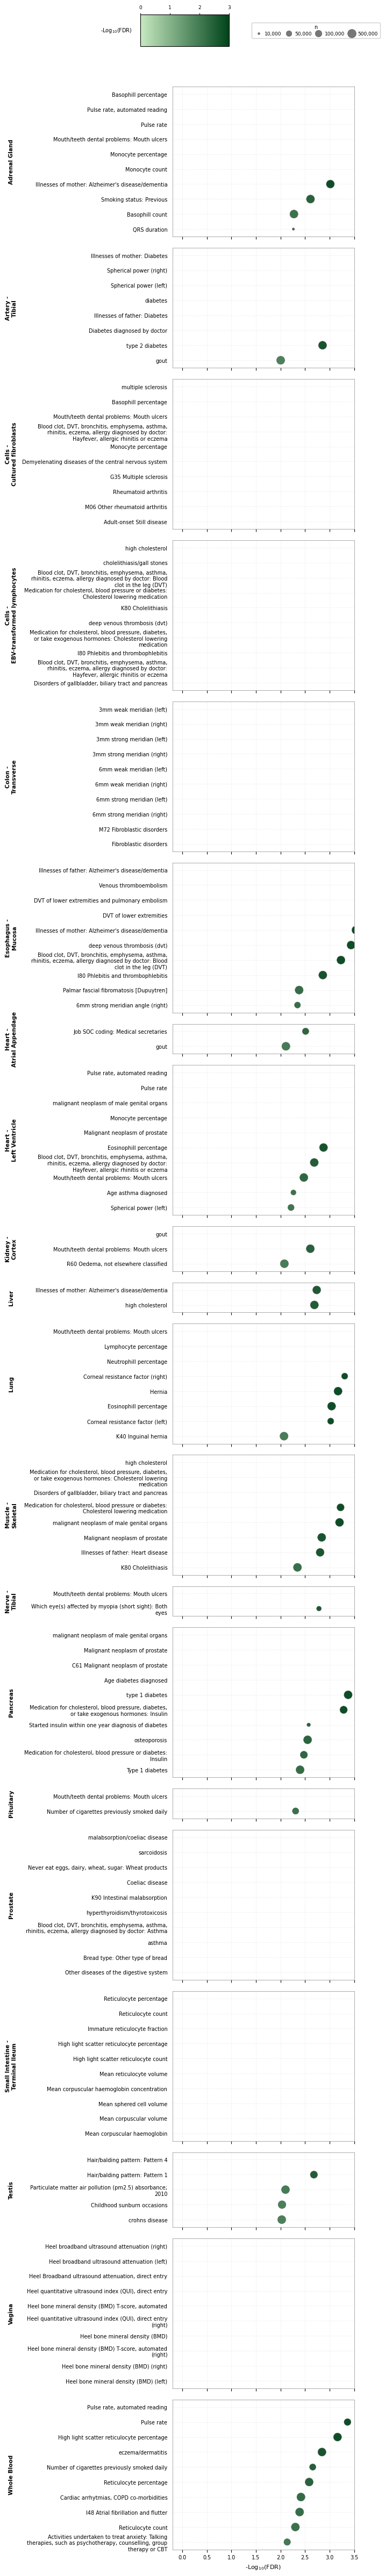

In [18]:
# Individual tissues | seen_lvs=True  | FDR < 0.01
plot_traits(tissues_ordered, top_per_tissue,
            fdr_thresh=0.01, use_seen_lvs=True, group_label=False)

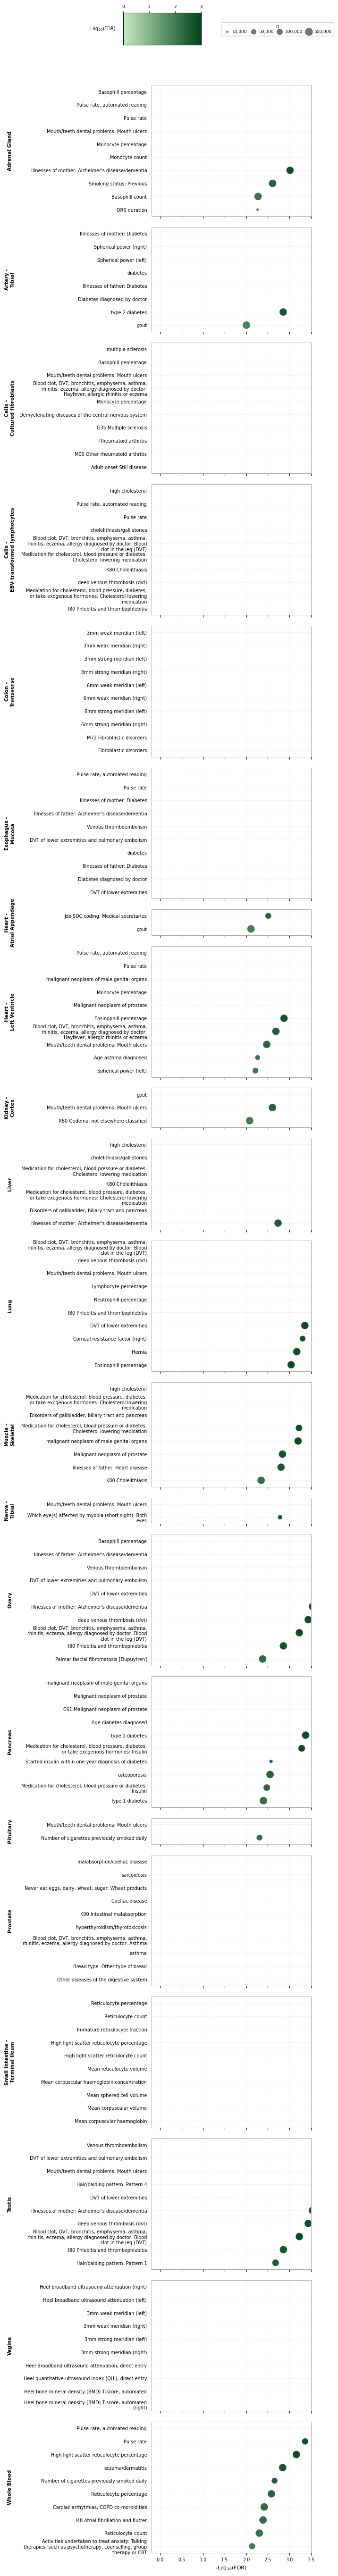

In [19]:
# Individual tissues | seen_lvs=False | FDR < 0.01
plot_traits(tissues_ordered, top_per_tissue,
            fdr_thresh=0.01, use_seen_lvs=False, group_label=False)

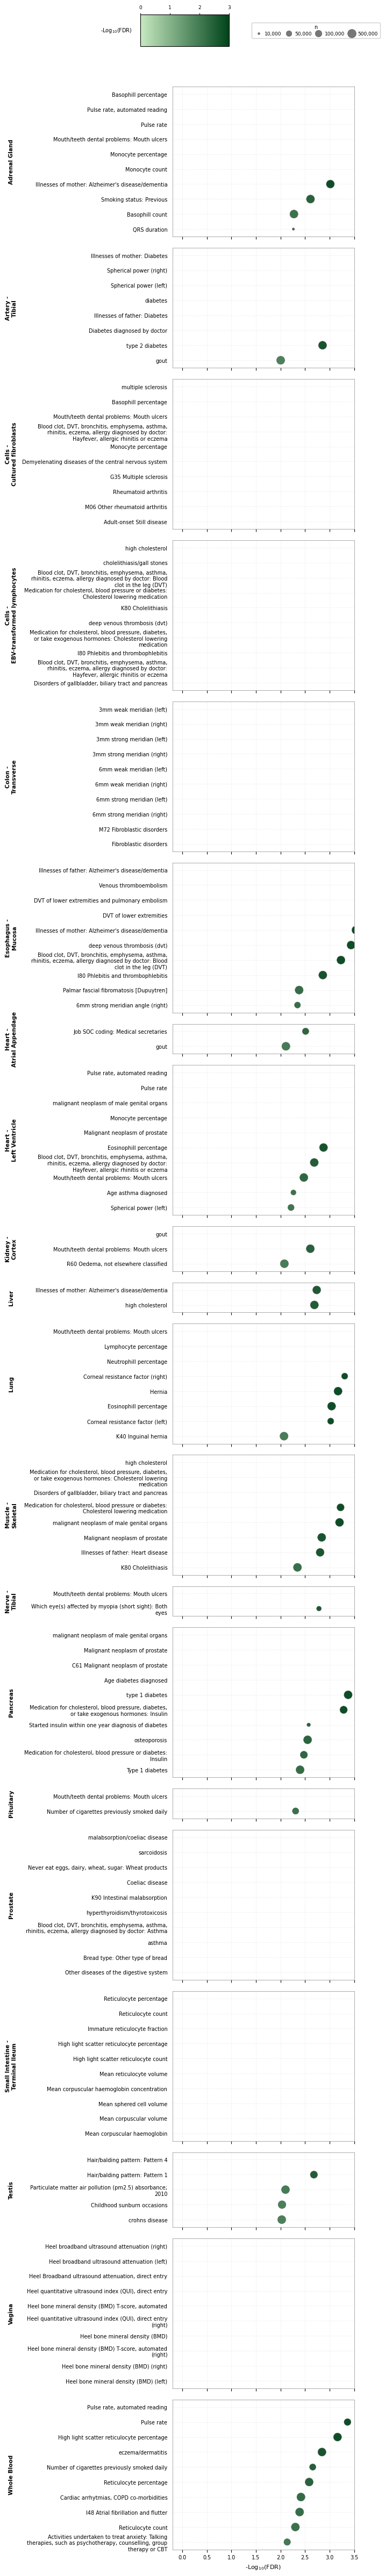

In [20]:
# Individual tissues | seen_lvs=True  | FDR < 0.05
plot_traits(tissues_ordered, top_per_tissue,
            fdr_thresh=0.05, use_seen_lvs=True, group_label=False)

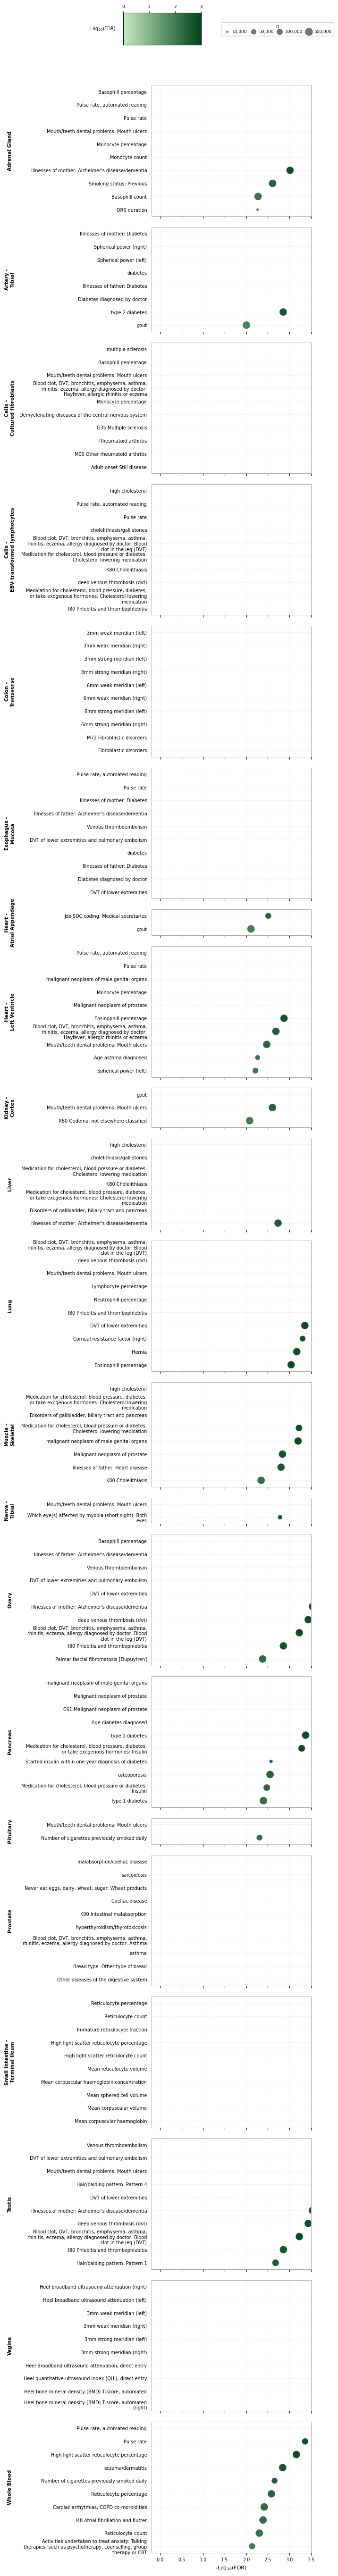

In [21]:
# Individual tissues | seen_lvs=False | FDR < 0.05
plot_traits(tissues_ordered, top_per_tissue,
            fdr_thresh=0.05, use_seen_lvs=False, group_label=False)

### Grouped tissues

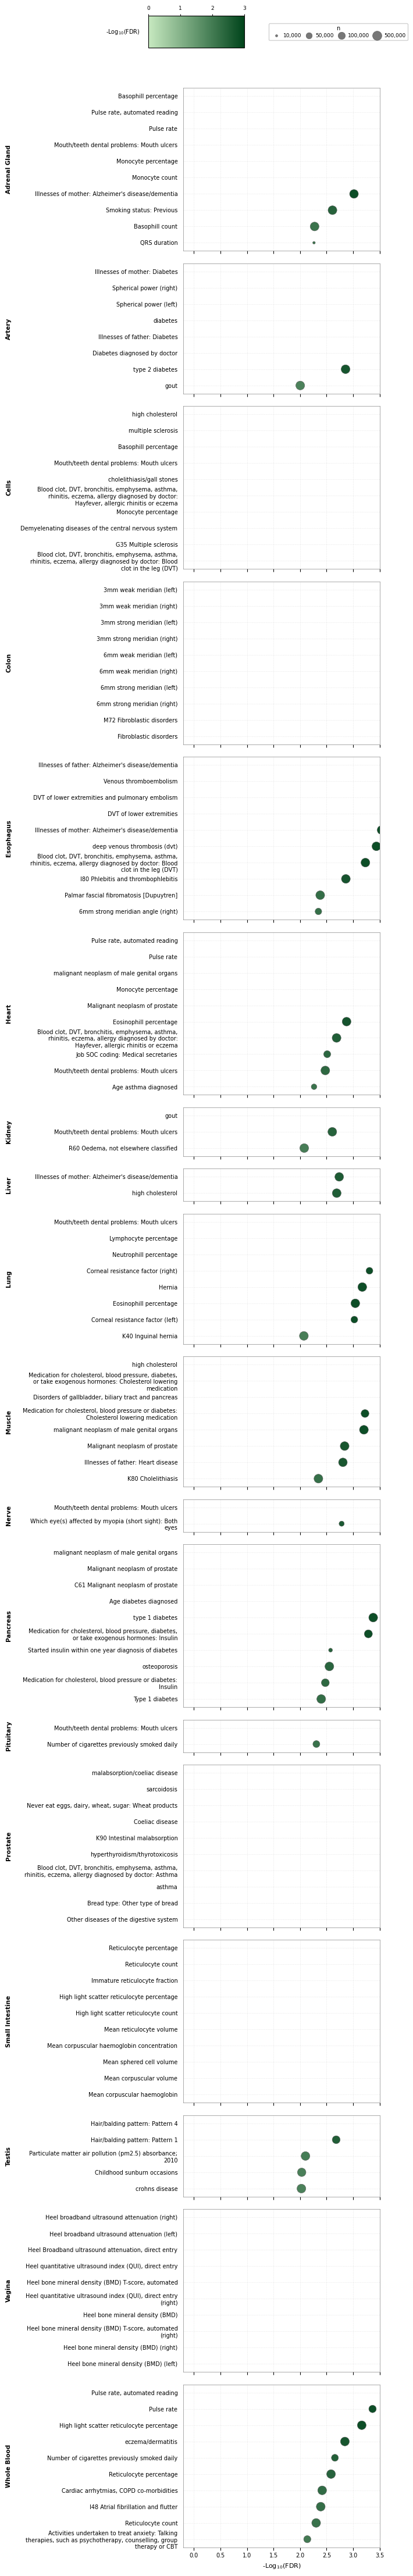

In [22]:
# Grouped tissues | seen_lvs=True  | FDR < 0.01
plot_traits(groups_ordered, group_to_lvs,
            fdr_thresh=0.01, use_seen_lvs=True, group_label=True)

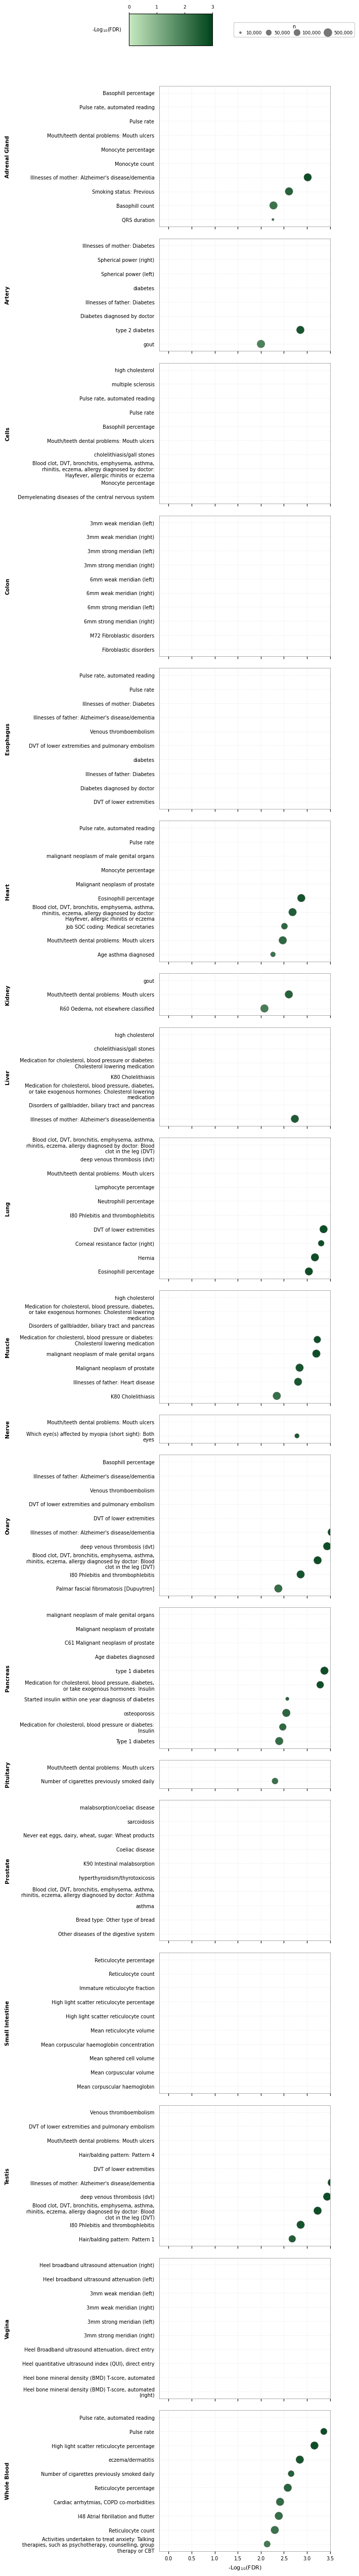

In [23]:
# Grouped tissues | seen_lvs=False | FDR < 0.01
plot_traits(groups_ordered, group_to_lvs,
            fdr_thresh=0.01, use_seen_lvs=False, group_label=True)

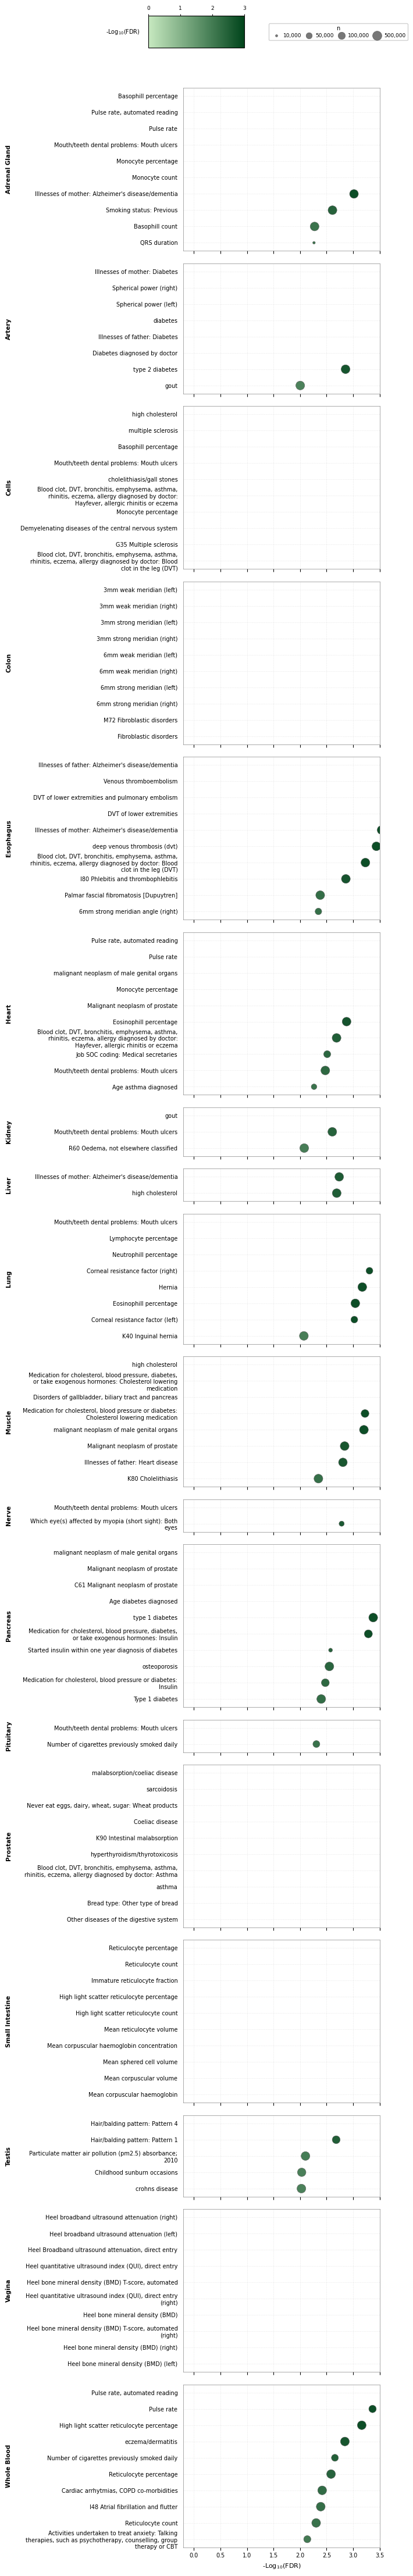

In [24]:
# Grouped tissues | seen_lvs=True  | FDR < 0.05
plot_traits(groups_ordered, group_to_lvs,
            fdr_thresh=0.05, use_seen_lvs=True, group_label=True)

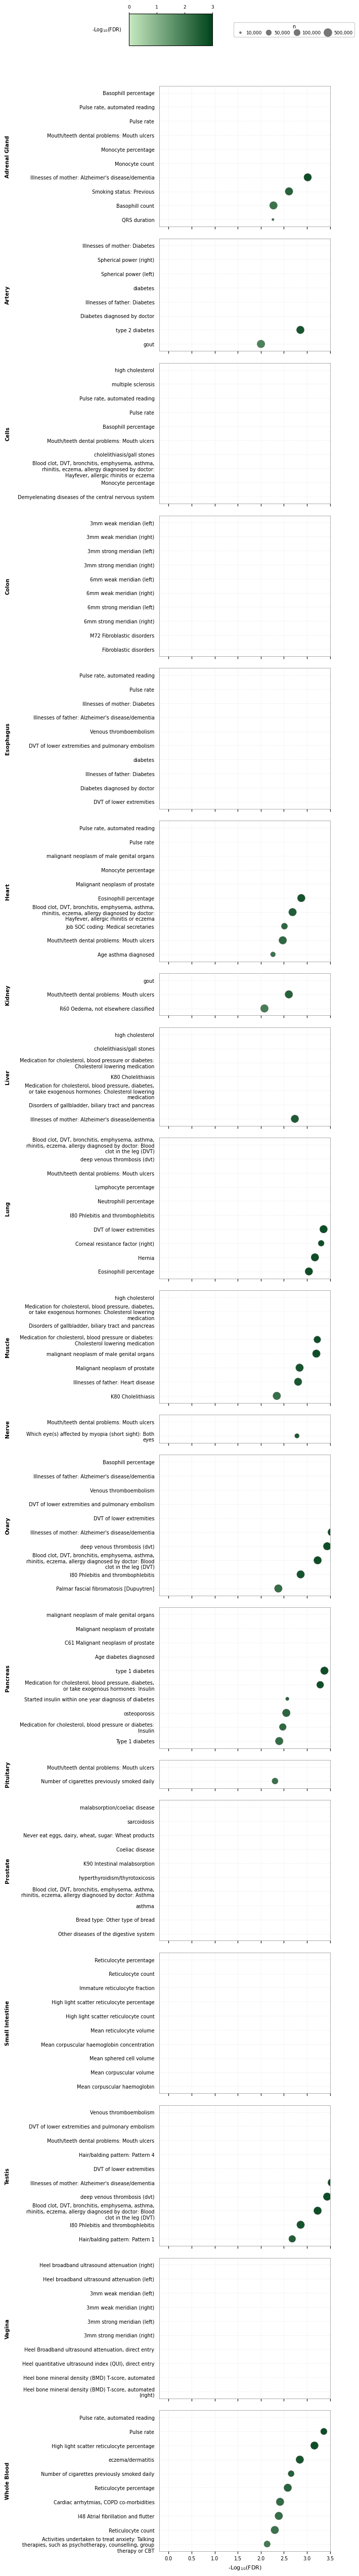

In [25]:
# Grouped tissues | seen_lvs=False | FDR < 0.05
plot_traits(groups_ordered, group_to_lvs,
            fdr_thresh=0.05, use_seen_lvs=False, group_label=True)

## BP

In [26]:
gtex_CLAMPfull_summary_sub = gtex_CLAMPfull_summary[(gtex_CLAMPfull_summary['AUC'] > 0.7) & (gtex_CLAMPfull_summary['FDR'] < 0.05)]

### Individual tissues

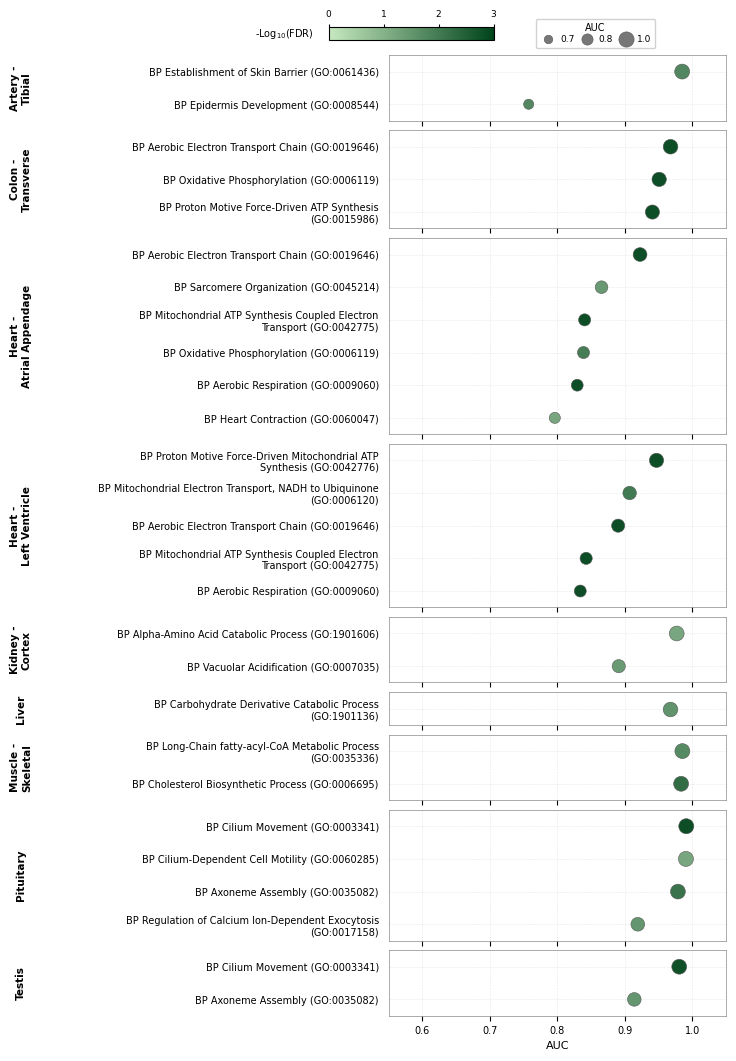

In [27]:
# Individual tissues | seen_lvs=True  | FDR < 0.05, AUC > 0.70
plot_bp(tissues_ordered, top_per_tissue,
        fdr_thresh=0.05, auc_thresh=0.7, use_seen_lvs=True, group_label=False)

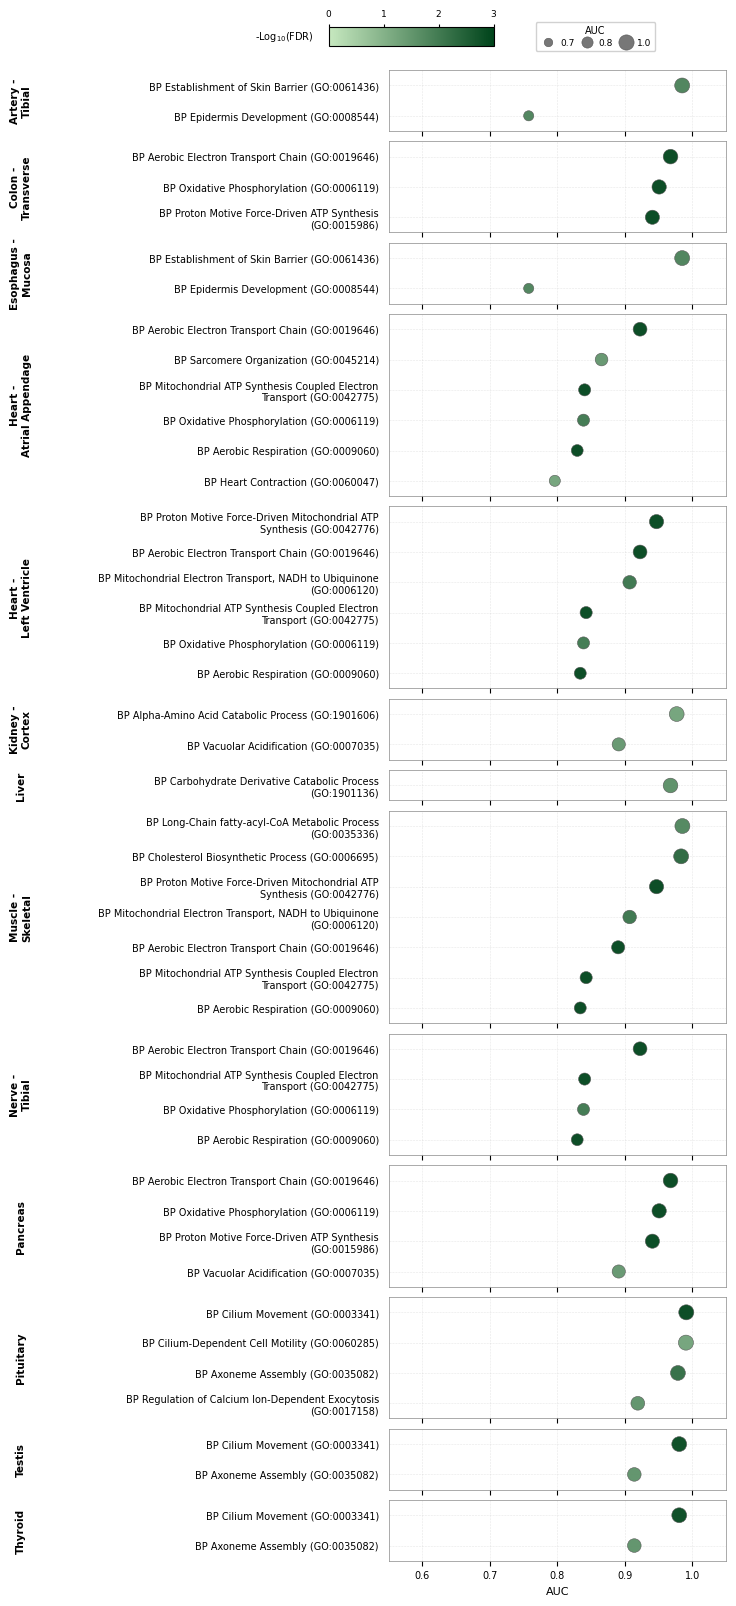

In [28]:
# Individual tissues | seen_lvs=False | FDR < 0.05, AUC > 0.70
plot_bp(tissues_ordered, top_per_tissue,
        fdr_thresh=0.05, auc_thresh=0.7, use_seen_lvs=False, group_label=False)

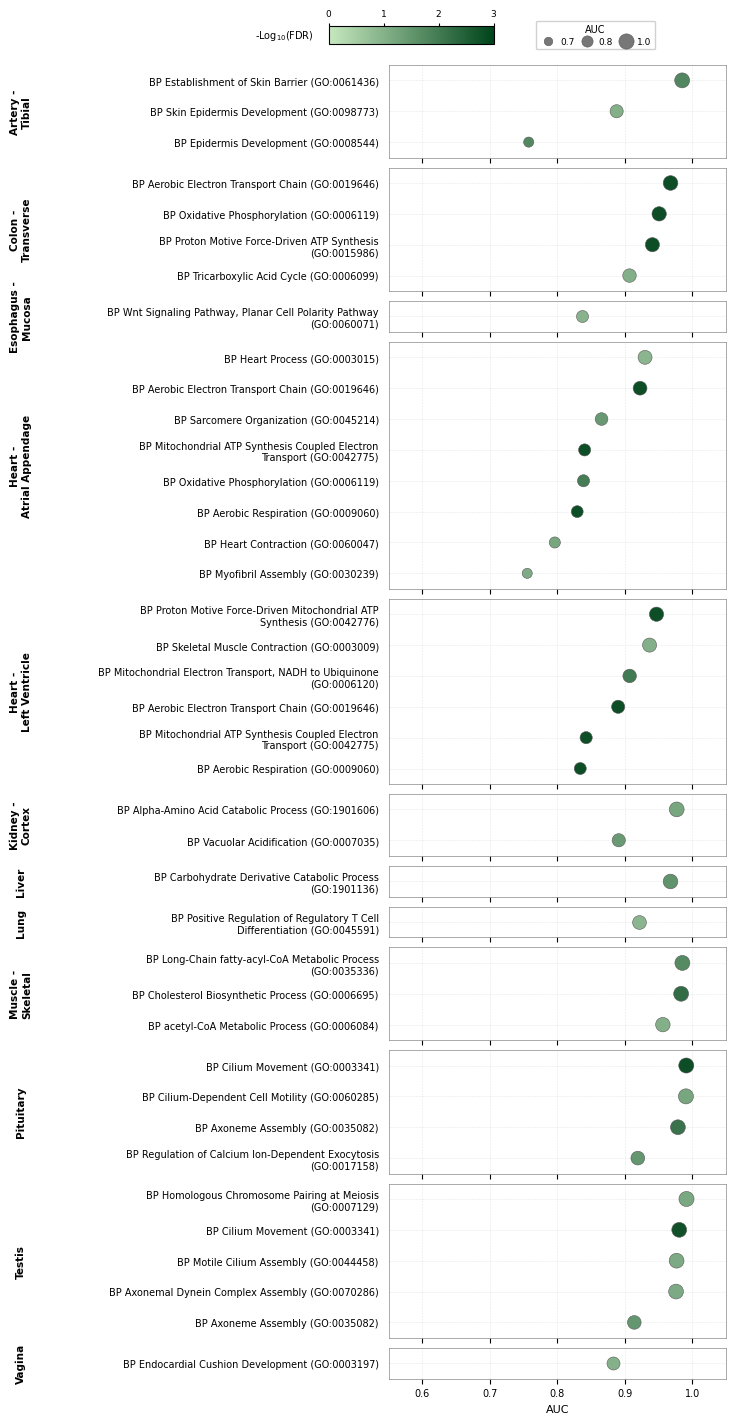

In [29]:
# Individual tissues | seen_lvs=True  | FDR < 0.10, AUC > 0.60
plot_bp(tissues_ordered, top_per_tissue,
        fdr_thresh=0.1, auc_thresh=0.6, use_seen_lvs=True, group_label=False)

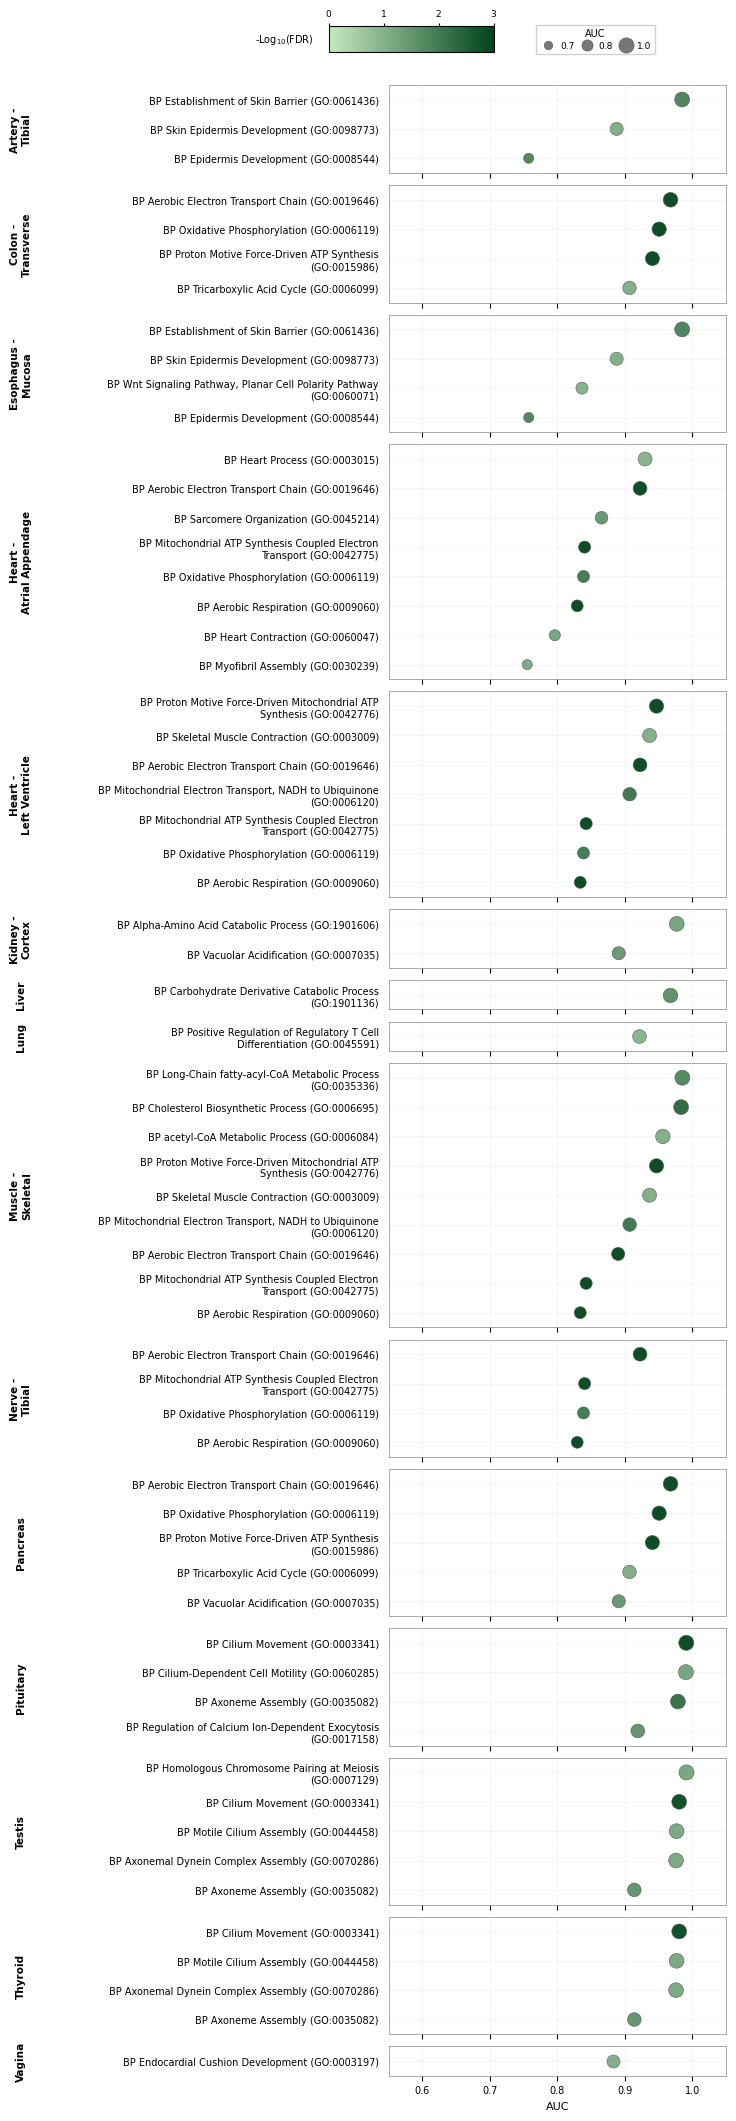

In [30]:
# Individual tissues | seen_lvs=False | FDR < 0.10, AUC > 0.60
plot_bp(tissues_ordered, top_per_tissue,
        fdr_thresh=0.1, auc_thresh=0.6, use_seen_lvs=False, group_label=False)

### Grouped tissues

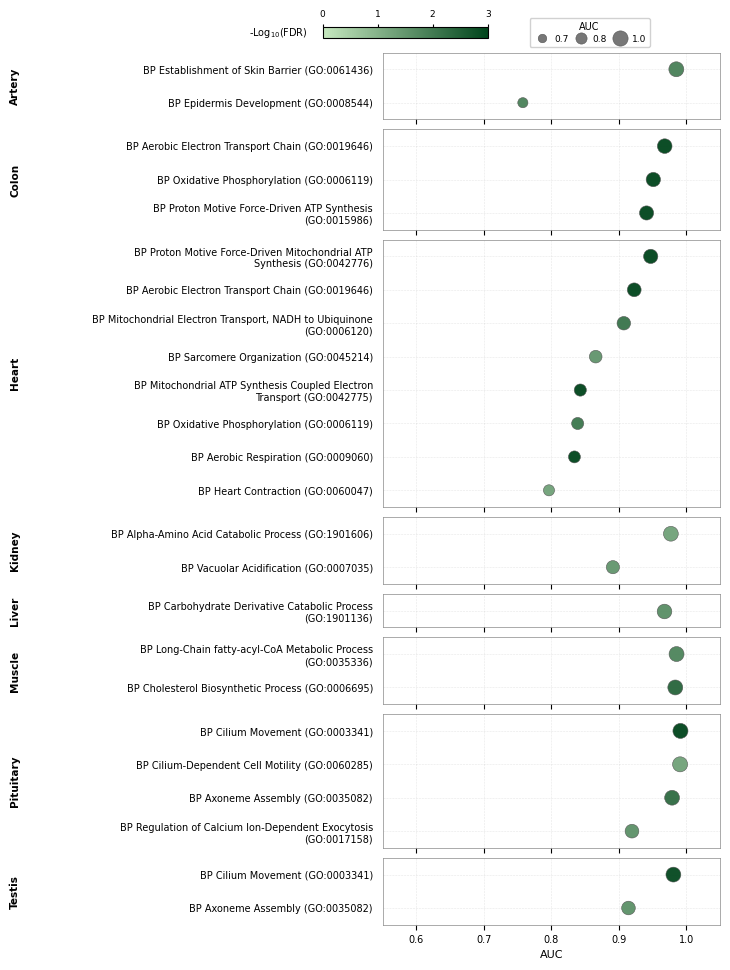

In [31]:
# Grouped tissues | seen_lvs=True  | FDR < 0.05, AUC > 0.70
plot_bp(groups_ordered, group_to_lvs,
        fdr_thresh=0.05, auc_thresh=0.7, use_seen_lvs=True, group_label=True)

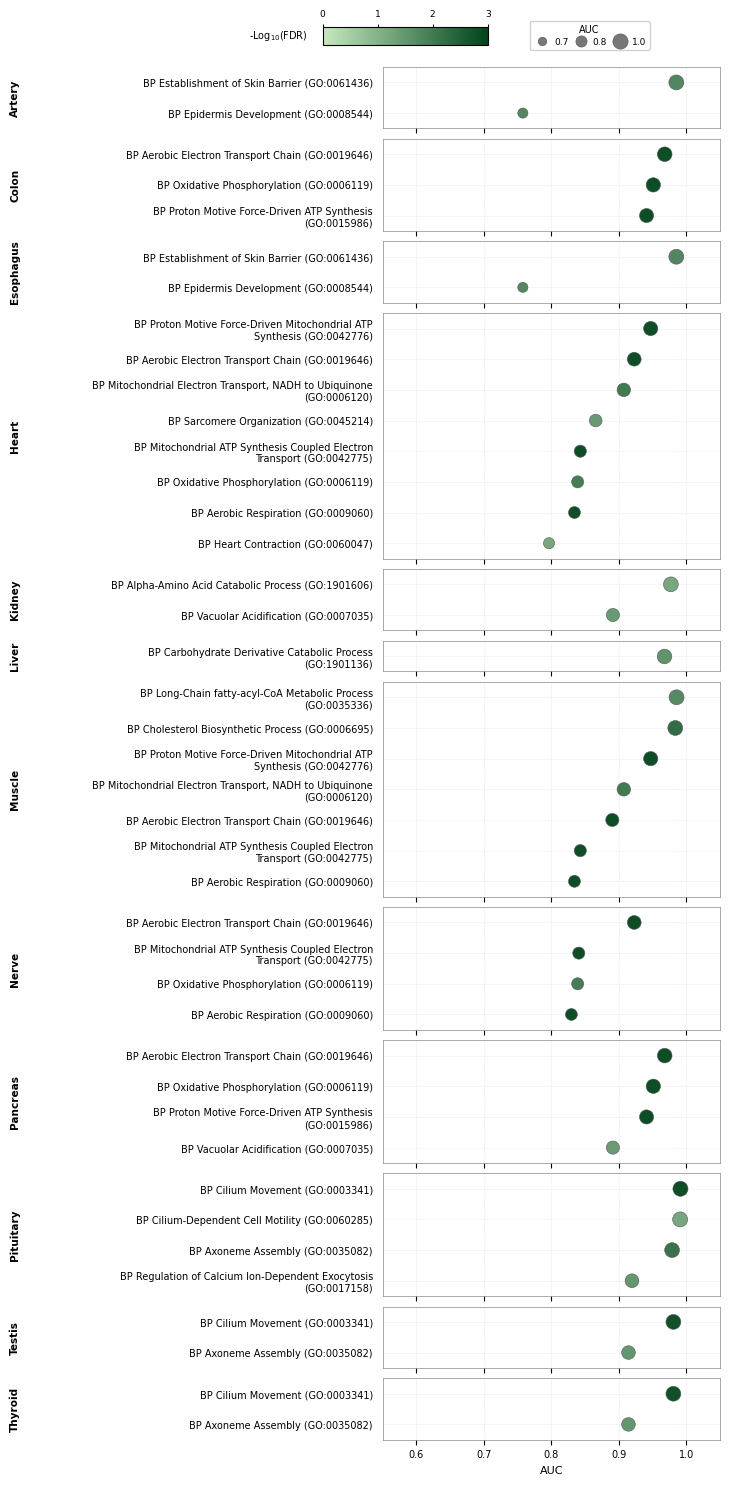

In [32]:
# Grouped tissues | seen_lvs=False | FDR < 0.05, AUC > 0.70
plot_bp(groups_ordered, group_to_lvs,
        fdr_thresh=0.05, auc_thresh=0.7, use_seen_lvs=False, group_label=True)

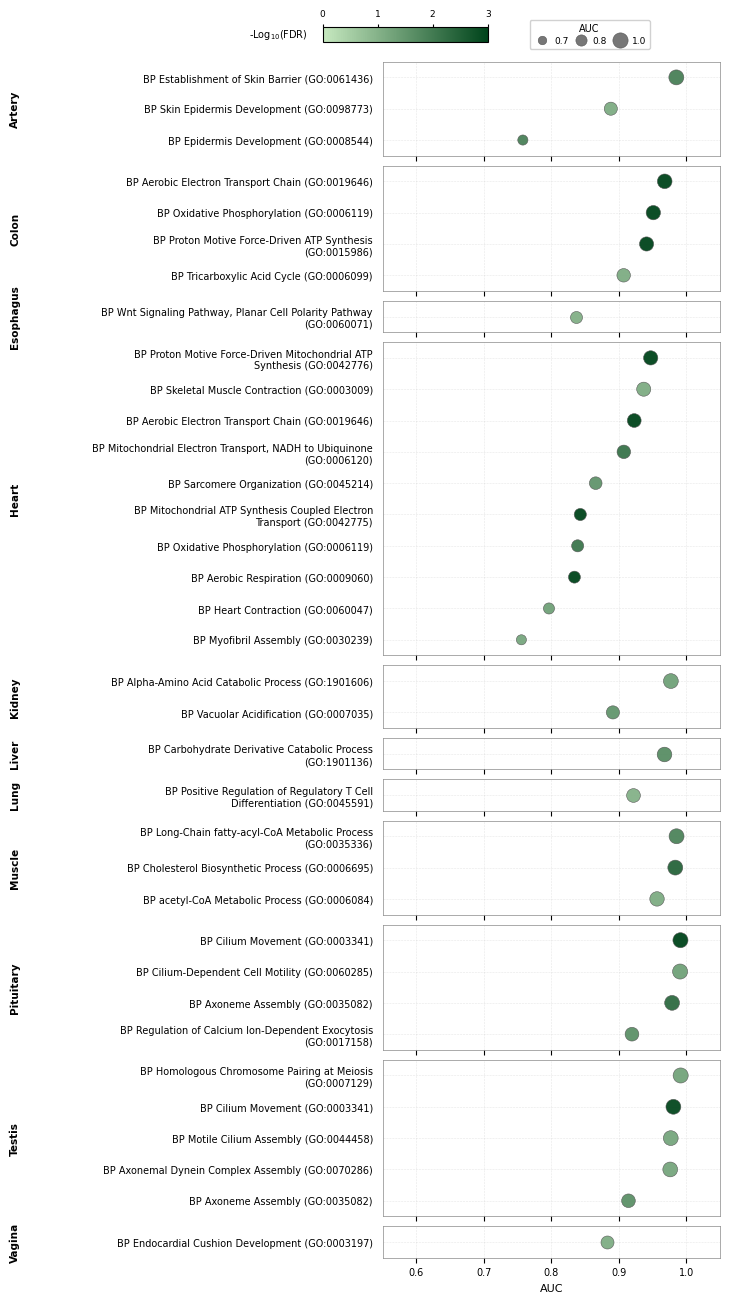

In [33]:
# Grouped tissues | seen_lvs=True  | FDR < 0.10, AUC > 0.60
plot_bp(groups_ordered, group_to_lvs,
        fdr_thresh=0.1, auc_thresh=0.6, use_seen_lvs=True, group_label=True)

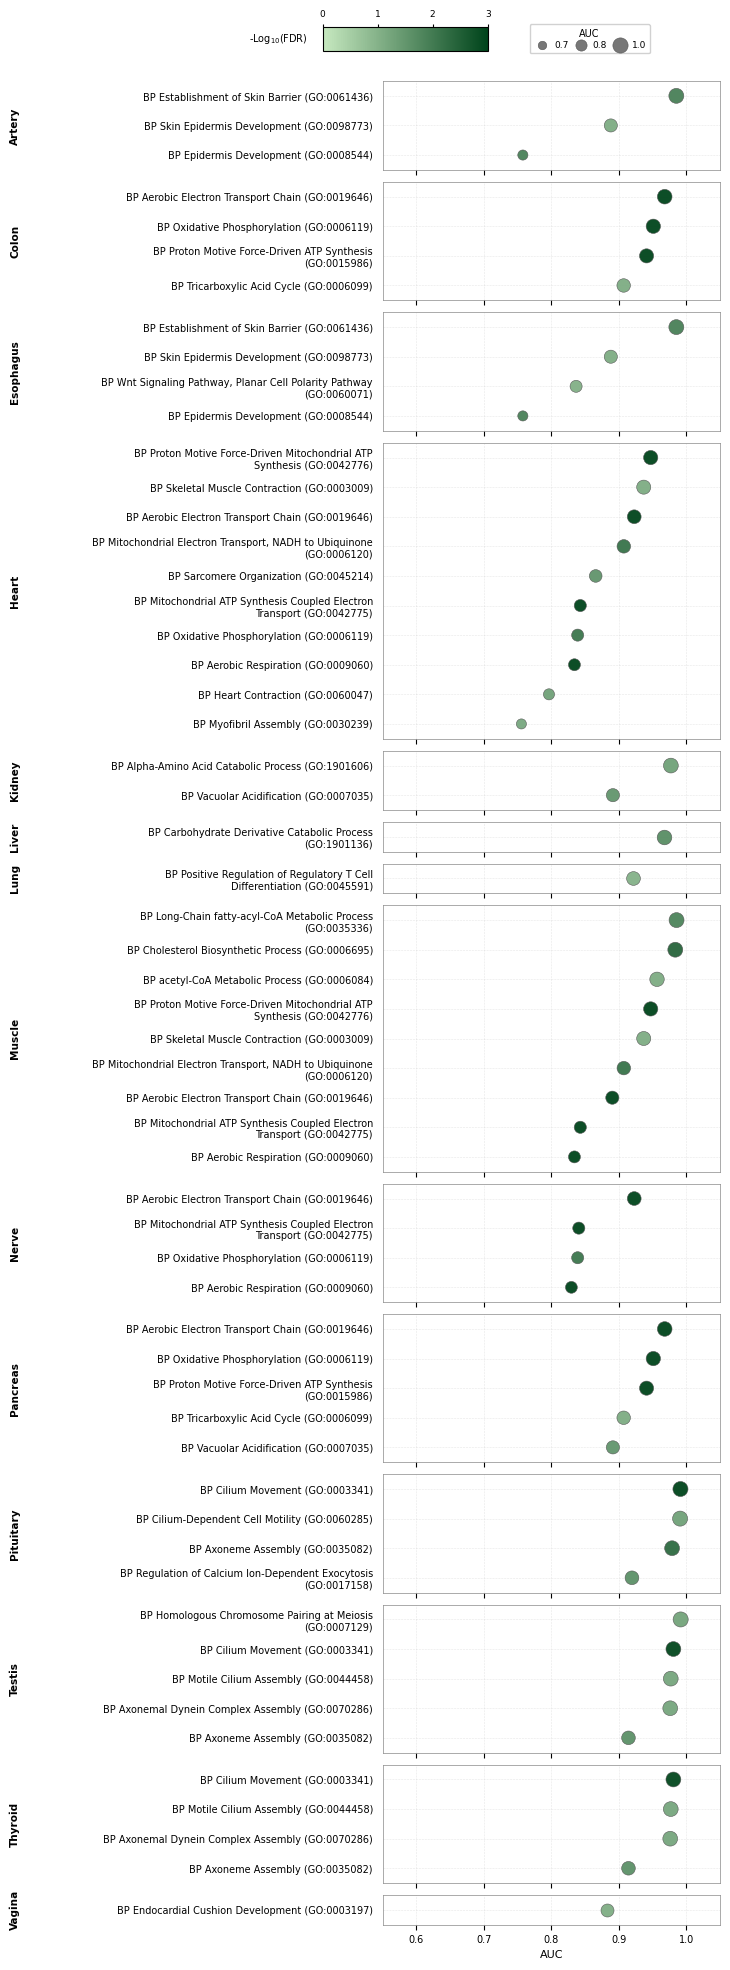

In [34]:
# Grouped tissues | seen_lvs=False | FDR < 0.10, AUC > 0.60
plot_bp(groups_ordered, group_to_lvs,
        fdr_thresh=0.1, auc_thresh=0.6, use_seen_lvs=False, group_label=True)